# Training a Transformer From Scratch

This notebook walks through the complete training pipeline, building each piece
from first principles before using the library versions:

1. **Data loading** — how training data is prepared and batched
2. **The training loop** — forward pass, loss, backward pass, optimizer step
3. **Cross-entropy loss** — why this is the right loss for next-token prediction
4. **Gradient descent** — how parameters get updated

We use the same tiny 8-token vocabulary from `01_transformer_internals/00_transformer_overview.ipynb`
so you can focus on the training mechanics, not the data.

### References
- [docs/PAPERS.md § Training Optimization](../../docs/PAPERS.md#training-optimization)
- Training code: `src/ai_playground/training/trainer.py`
- Data code: `src/ai_playground/training/data.py`

> 📺 **Video companion:** [Let's reproduce GPT-2 (Karpathy)](https://www.youtube.com/watch?v=l8pRSuU81PU) runs this same training loop at GPT-2 scale, with the same ingredients — more in [Videos](../../docs/VIDEOS.md).

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ggreg/ai_playground/blob/main/notebooks/02_training_optimization/00_training_from_scratch.ipynb)

In [1]:
# Setup — works from a repo checkout (via ../src) or standalone on Colab
import sys
sys.path.insert(0, '../src')
try:
    import ai_playground  # noqa: F401
except ImportError:
    %pip install -q git+https://github.com/ggreg/ai_playground.git

In [2]:
import sys
sys.path.insert(0, '../src')

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import math
import time

from ai_playground.models import Transformer, TransformerConfig

torch.manual_seed(42)
device = 'cpu'

## 1. Preparing Training Data

Language model training uses **next-token prediction**: given a sequence of tokens,
predict the next one at every position simultaneously.

```
Input:   the  cat  sat  on  the
Target:  cat  sat  on   the mat
```

The target is just the input shifted by one position. This is how the model
learns language — by trying to predict what comes next, billions of times.

See `src/ai_playground/training/data.py` for the `TextDataset` implementation.

In [3]:
# Our tiny vocabulary
VOCAB = ['<pad>', 'the', 'cat', 'dog', 'sat', 'ran', 'on', 'mat']
tok2id = {t: i for i, t in enumerate(VOCAB)}
id2tok = {i: t for t, i in tok2id.items()}
vocab_size = len(VOCAB)

def tokenize(s):
    return [tok2id[w] for w in s.split()]

# Training sentences
sentences = [
    'the cat sat on the mat',
    'the dog ran on the mat',
    'the cat ran on the mat',
    'the dog sat on the mat',
]

# Build input/target pairs: input[t] predicts target[t] = input[t+1]
all_tokens = [tokenize(s) for s in sentences]
train_x = torch.tensor([t[:-1] for t in all_tokens])  # (4, 5)
train_y = torch.tensor([t[1:] for t in all_tokens])    # (4, 5)

print('Next-token prediction setup:')
print(f'  Batch size: {train_x.shape[0]}, Sequence length: {train_x.shape[1]}\n')
for i in range(len(sentences)):
    inp = [id2tok[j.item()] for j in train_x[i]]
    tgt = [id2tok[j.item()] for j in train_y[i]]
    for pos in range(len(inp)):
        print(f'  Given [{" ".join(inp[:pos+1])}] → predict "{tgt[pos]}"')
    print()

Next-token prediction setup:
  Batch size: 4, Sequence length: 5

  Given [the] → predict "cat"
  Given [the cat] → predict "sat"
  Given [the cat sat] → predict "on"
  Given [the cat sat on] → predict "the"
  Given [the cat sat on the] → predict "mat"

  Given [the] → predict "dog"
  Given [the dog] → predict "ran"
  Given [the dog ran] → predict "on"
  Given [the dog ran on] → predict "the"
  Given [the dog ran on the] → predict "mat"

  Given [the] → predict "cat"
  Given [the cat] → predict "ran"
  Given [the cat ran] → predict "on"
  Given [the cat ran on] → predict "the"
  Given [the cat ran on the] → predict "mat"

  Given [the] → predict "dog"
  Given [the dog] → predict "sat"
  Given [the dog sat] → predict "on"
  Given [the dog sat on] → predict "the"
  Given [the dog sat on the] → predict "mat"



## 2. The Training Loop — Step by Step

Every training step has four phases:

1. **Forward pass**: input → model → logits (predictions)
2. **Loss**: compare predictions to targets → single number measuring "how wrong"
3. **Backward pass**: compute gradients (how to adjust each parameter to reduce loss)
4. **Optimizer step**: update parameters using gradients

Let's do this manually first, then use the `Trainer` class.

In [4]:
# Build a tiny model
config = TransformerConfig(
    vocab_size=vocab_size, dim=32, n_layers=2, n_heads=4,
    n_kv_heads=2, max_seq_len=16, ffn_dim_multiplier=2.0,
)
model = Transformer(config).to(device)
print(f'Model: {sum(p.numel() for p in model.parameters()):,} parameters\n')

# ============ Step 1: Forward pass ============
# Feed tokens through the model to get logits (one score per vocab token)
logits = model(train_x)  # (batch=4, seq=5, vocab=8)
print(f'1. FORWARD PASS')
print(f'   Input shape:  {train_x.shape}  (batch, seq_len)')
print(f'   Output shape: {logits.shape}  (batch, seq_len, vocab_size)')
print(f'   Each position produces {vocab_size} scores — one per vocab token\n')

# Show raw logits for first sentence, first position
print(f'   Raw logits at position 0 (after "the"):')
for j, v in enumerate(VOCAB):
    print(f'     {v:>5s}: {logits[0, 0, j].item():+.3f}')
print()

# ============ Step 2: Loss ============
# Cross-entropy loss: measures how surprised the model is by the correct answer
# Reshape for PyTorch: (batch*seq, vocab) vs (batch*seq,)
loss = F.cross_entropy(logits.view(-1, vocab_size), train_y.view(-1))
print(f'2. LOSS')
print(f'   Cross-entropy loss: {loss.item():.4f}')
print(f'   Random guessing would give: ln({vocab_size}) = {math.log(vocab_size):.4f}')
print(f'   Perfect predictions would give: ~0.0')
print(f'   Current model is {"worse than" if loss.item() > math.log(vocab_size) else "better than"} random\n')

# ============ Step 3: Backward pass ============
# Compute gradients: for each parameter, how does changing it affect the loss?
loss.backward()

# Show gradient statistics for one layer
first_param = list(model.parameters())[0]
print(f'3. BACKWARD PASS')
print(f'   Gradients computed for all {sum(1 for p in model.parameters()):} parameter tensors')
print(f'   Example: embedding layer gradient shape = {first_param.grad.shape}')
print(f'   Gradient magnitude (L2 norm): {first_param.grad.norm().item():.6f}')
print(f'   This tells us the direction to nudge each parameter\n')

# ============ Step 4: Optimizer step ============
# AdamW updates parameters using gradients + momentum
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

# Snapshot a weight before
w_before = model.tok_embeddings.weight[1].clone()  # "the" embedding

optimizer.step()
optimizer.zero_grad()

w_after = model.tok_embeddings.weight[1]  # after update
w_delta = (w_after - w_before).norm().item()

print(f'4. OPTIMIZER STEP (AdamW)')
print(f'   Embedding for "the" moved by {w_delta:.6f} (L2 distance)')
print(f'   Every parameter shifted slightly to reduce the loss')
print(f'   Repeat this 1000s of times → model learns the patterns')

Model: 19,104 parameters

1. FORWARD PASS
   Input shape:  torch.Size([4, 5])  (batch, seq_len)
   Output shape: torch.Size([4, 5, 8])  (batch, seq_len, vocab_size)
   Each position produces 8 scores — one per vocab token

   Raw logits at position 0 (after "the"):
     <pad>: +0.016
       the: +0.160
       cat: -0.095
       dog: -0.080
       sat: +0.094
       ran: +0.181
        on: -0.125
       mat: -0.015

2. LOSS
   Cross-entropy loss: 2.1666
   Random guessing would give: ln(8) = 2.0794
   Perfect predictions would give: ~0.0
   Current model is worse than random

3. BACKWARD PASS
   Gradients computed for all 21 parameter tensors
   Example: embedding layer gradient shape = torch.Size([8, 32])
   Gradient magnitude (L2 norm): 1.754817
   This tells us the direction to nudge each parameter



4. OPTIMIZER STEP (AdamW)
   Embedding for "the" moved by 0.005657 (L2 distance)
   Every parameter shifted slightly to reduce the loss
   Repeat this 1000s of times → model learns the patterns


## 3. Cross-Entropy Loss Explained

Cross-entropy measures how surprised the model is by the correct answer.

If the model assigns probability `p` to the correct token, the loss for that position is `-log(p)`:
- Model is 90% confident on the right answer → loss = -log(0.9) = 0.105 (low, good!)
- Model is 10% confident → loss = -log(0.1) = 2.303 (high, bad!)
- Random guessing (1/8 = 12.5% per token) → loss = -log(1/8) = 2.079

The total loss is averaged across all positions and all sentences in the batch.

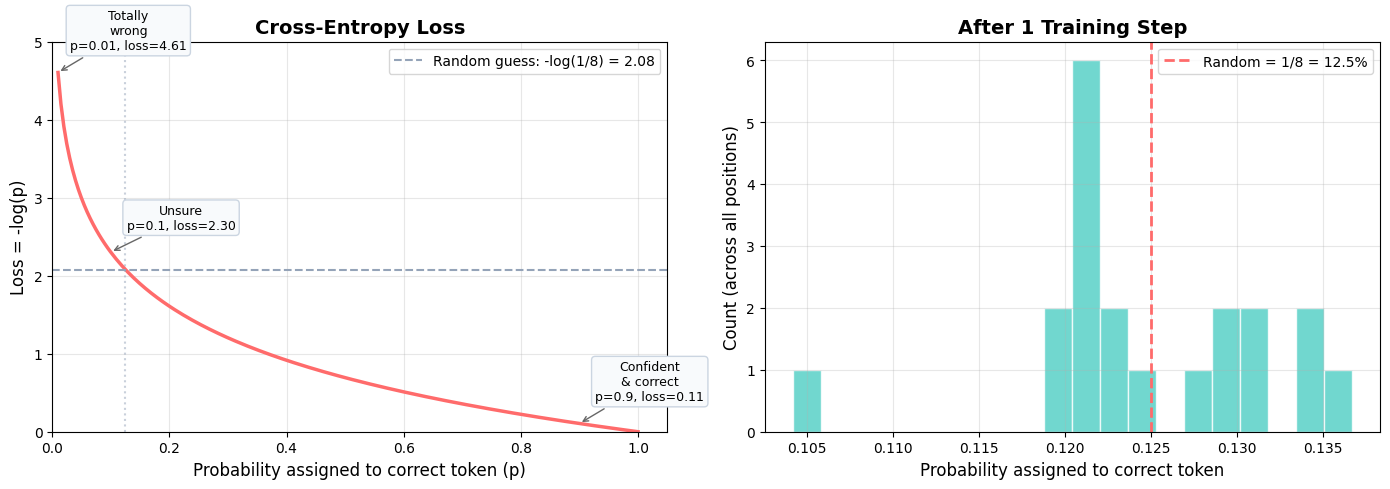

Average probability on correct token: 12.5%
Random would be: 12.5%


In [5]:
# Visualize cross-entropy loss function
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: -log(p) curve
p = np.linspace(0.01, 1.0, 200)
ax1.plot(p, -np.log(p), color='#FF6B6B', linewidth=2.5)
ax1.axhline(y=-np.log(1/vocab_size), color='#94A3B8', linestyle='--',
            label=f'Random guess: -log(1/{vocab_size}) = {-np.log(1/vocab_size):.2f}')
ax1.axvline(x=1/vocab_size, color='#94A3B8', linestyle=':', alpha=0.5)
ax1.set_xlabel('Probability assigned to correct token (p)', fontsize=12)
ax1.set_ylabel('Loss = -log(p)', fontsize=12)
ax1.set_title('Cross-Entropy Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1.05)
ax1.set_ylim(0, 5)

# Annotate key points
for prob, label in [(0.9, 'Confident\n& correct'), (0.1, 'Unsure'), (0.01, 'Totally\nwrong')]:
    loss_val = -np.log(prob)
    ax1.annotate(f'{label}\np={prob}, loss={loss_val:.2f}',
                xy=(prob, loss_val), fontsize=9, ha='center',
                xytext=(prob + 0.12, loss_val + 0.3),
                arrowprops=dict(arrowstyle='->', color='#666'),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='#F8FAFC', edgecolor='#CBD5E1'))

# Right: compare loss before and after some training
with torch.no_grad():
    logits_now = model(train_x)
    probs_now = F.softmax(logits_now, dim=-1)

# Gather probabilities assigned to the correct target tokens
correct_probs = probs_now.gather(2, train_y.unsqueeze(-1)).squeeze(-1)  # (4, 5)
all_probs = correct_probs.flatten().numpy()

ax2.hist(all_probs, bins=20, color='#4ECDC4', edgecolor='white', alpha=0.8)
ax2.axvline(x=1/vocab_size, color='#FF6B6B', linestyle='--', linewidth=2,
            label=f'Random = 1/{vocab_size} = {1/vocab_size:.1%}')
ax2.set_xlabel('Probability assigned to correct token', fontsize=12)
ax2.set_ylabel('Count (across all positions)', fontsize=12)
ax2.set_title('After 1 Training Step', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Average probability on correct token: {all_probs.mean():.1%}')
print(f'Random would be: {1/vocab_size:.1%}')

## 4. Gradient Descent Visualized

Gradients tell us the slope of the loss landscape — which direction to move
each parameter to reduce the loss. The optimizer takes a step in that direction.

Let's watch a single parameter (one value in the embedding of "cat") as we train.

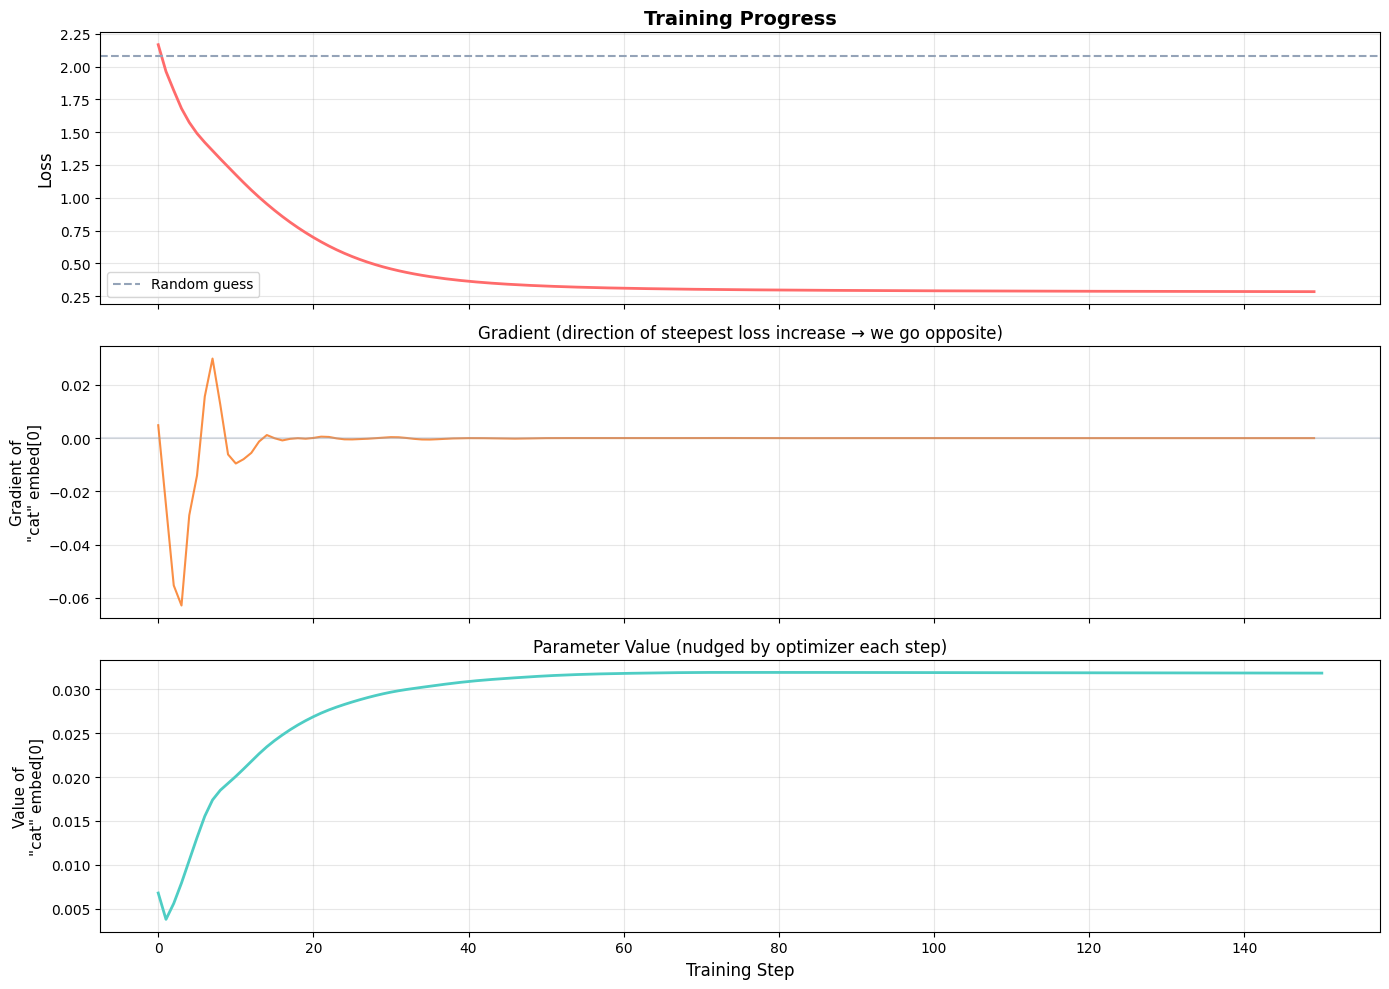

"cat" embedding[0] moved from 0.0068 to 0.0318
That's a total shift of 0.0250


In [6]:
# Reset model for clean tracking
torch.manual_seed(42)
model = Transformer(config).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)

# Track one specific parameter over training
param_idx = (tok2id['cat'], 0)  # first dimension of "cat" embedding
param_history = []
loss_history = []
grad_history = []

n_steps = 150
model.train()
for step in range(n_steps):
    logits = model(train_x)
    loss = F.cross_entropy(logits.view(-1, vocab_size), train_y.view(-1))

    optimizer.zero_grad()
    loss.backward()

    # Record before optimizer step
    param_val = model.tok_embeddings.weight[param_idx[0], param_idx[1]].item()
    grad_val = model.tok_embeddings.weight.grad[param_idx[0], param_idx[1]].item()
    param_history.append(param_val)
    loss_history.append(loss.item())
    grad_history.append(grad_val)

    optimizer.step()

# Final value
param_history.append(model.tok_embeddings.weight[param_idx[0], param_idx[1]].item())

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# Loss over time
axes[0].plot(loss_history, color='#FF6B6B', linewidth=2)
axes[0].axhline(y=np.log(vocab_size), color='#94A3B8', linestyle='--', label='Random guess')
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Progress', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Gradient over time
axes[1].plot(grad_history, color='#F97316', linewidth=1.5, alpha=0.8)
axes[1].axhline(y=0, color='#94A3B8', linestyle='-', alpha=0.3)
axes[1].set_ylabel(f'Gradient of\n"cat" embed[0]', fontsize=11)
axes[1].set_title('Gradient (direction of steepest loss increase → we go opposite)', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Parameter value over time
axes[2].plot(param_history, color='#4ECDC4', linewidth=2)
axes[2].set_ylabel(f'Value of\n"cat" embed[0]', fontsize=11)
axes[2].set_xlabel('Training Step', fontsize=12)
axes[2].set_title('Parameter Value (nudged by optimizer each step)', fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'"cat" embedding[0] moved from {param_history[0]:.4f} to {param_history[-1]:.4f}')
print(f'That\'s a total shift of {abs(param_history[-1] - param_history[0]):.4f}')

## Key Takeaways

1. **Training = forward → loss → backward → update, repeated.** That's the entire algorithm.
2. **Cross-entropy loss** = `-log(probability of correct token)`. Lower = model is less surprised.
3. **Gradients** point toward steeper loss — the optimizer steps in the opposite direction.
4. **Each parameter gets its own gradient** — the model has thousands of knobs being tuned simultaneously.

### Next notebooks
- `01_learning_rate_schedules.ipynb` — why LR matters and how cosine annealing works
- `02_mixed_precision.ipynb` — train 2x faster with half-precision floats
- `03_gradient_accumulation.ipynb` — simulate large batches on small hardware
- `04_adamw_from_scratch.ipynb` — build the optimizer step by step

### References
- [AdamW](https://arxiv.org/abs/1711.05101) (Loshchilov & Hutter, 2019)
- [docs/PAPERS.md § Training Optimization](../../docs/PAPERS.md#training-optimization)